# Introduction to Machine Learning (CSCI-UA.473)

### Programming Assignment 2
#### Due: November 3, 2025 at 11:59PM


#### Name: (your name goes here)
#### Email: (your NYU email goes here)

## Instructions

For this programming assignment, you may only use the libraries and functions that are imported. For example, if train_test_split is imported from sklearn.model_selection, you may not use other functions in sklearn. However, you may use any functions from numpy in your implementation.

Note: you will use the same dataset as in programming assignment 1.

In [5]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

import pandas as pd
from pathlib import Path

root = Path('/content/gdrive/MyDrive')
csv_path = root / 'ML473' / 'HW2' / 'hw1_dataset.csv'

print(csv_path)                            # sanity check
assert csv_path.exists(), "Path is wrong. Check folder/file name."

data = pd.read_csv(csv_path)
X_orig = data.drop('target', axis=1)
y_orig = data['target'].values


Mounted at /content/gdrive
/content/gdrive/MyDrive/ML473/HW2/hw1_dataset.csv


In [6]:
y_orig[:10]

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310.])

In [7]:
y = np.where(y_orig > np.median(y_orig), 1, 0)

In [8]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_orig, y, test_size=0.2, random_state=42)

### Question 1: ROC curve and AUROC (15 points)

#### Task 1.1 (5 points)
Imagine you are a public health researcher investigating the performance of a new diagnostic test for disease Z, which is a potentially life-threatening condition. The test is designed to identify individuals who have the disease. You have collected data from a group of 500 patients who were tested for disease Z, and the results are as follows:

Out of 150 patients who actually have disease Z, the test correctly identified 120 of them as positive.
However, the test also falsely identified 50 patients who do not have disease Z as positive.

* **Precision:** Define precision in the context of this diagnostic test for disease Z. Calculate the precision of the test based on the provided data.
* **Recall:** Explain what recall means in this scenario. Calculate the recall of the test based on the provided data.
* **F1-score:** Define the F1-score and explain why it is important, especially in the context of diagnosing a serious disease like Z. Calculate the F1-score of the test based on the provided data.
* **Specificity:** What is specificity, and why is it relevant when evaluating a diagnostic test like this one? Calculate the specificity of the test based on the provided data.
* **Balanced Accuracy:** Describe what balanced accuracy is and why it might be a useful metric in this situation. Calculate the balanced accuracy of the test based on the provided data.

**IMPORTANT: please implement all the calculations as functions; you will need them in Question 3**

In [9]:
def precision(tp, fp): return tp / (tp + fp) if (tp+fp) else 0.0
def recall(tp, fn):    return tp / (tp + fn) if (tp+fn) else 0.0
def f1(tp, fp, fn):
    p, r = precision(tp, fp), recall(tp, fn)
    return 2*p*r/(p+r) if (p+r) else 0.0
def specificity(tn, fp): return tn / (tn + fp) if (tn+fp) else 0.0
def balanced_accuracy(tp, fp, tn, fn):
    return 0.5 * (recall(tp, fn) + specificity(tn, fp))

# Using the given numbers:
TP, FP, TN, FN = 120, 50, 300, 30
P = precision(TP, FP)
R = recall(TP, FN)
F1 = f1(TP, FP, FN)
SPEC = specificity(TN, FP)
BA = balanced_accuracy(TP, FP, TN, FN)

P, R, F1, SPEC, BA
# -> (~0.70588, 0.8, 0.75, ~0.85714, ~0.82857)


(0.7058823529411765,
 0.8,
 0.7500000000000001,
 0.8571428571428571,
 0.8285714285714285)

#### Task 1.2 (5 Points)

For this question, you will need to implement an SVM with a linear kernel. Please refer to Question 3 (Task 3.1) for details. You may reuse your implementation for this question for Question 3.

Plot the ROC curve.

An ROC curve plots TPR (y-axis) vs. FPR (x-axis) at all classification thresholds. Lowering the classification threshold classifies more items as positive, thus increasing both False Positives and True Positives. For the classification threshold of an SVM, you should directly use the margins. Since the margins are not necessarily between zero and one, you will need to iterate through the thresholds from the minimum margin values to the maximum.

See this for more details (https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc)

Plot the ROC curve for Disease Z HW1 dataset with SVM classifier. **Note that you are not allowed to use any library function to compute the ROC. You have to do it from scratch (with NumPy).**

/tmp/ipython-input-2652466557.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, x)


AUROC = 0.8281


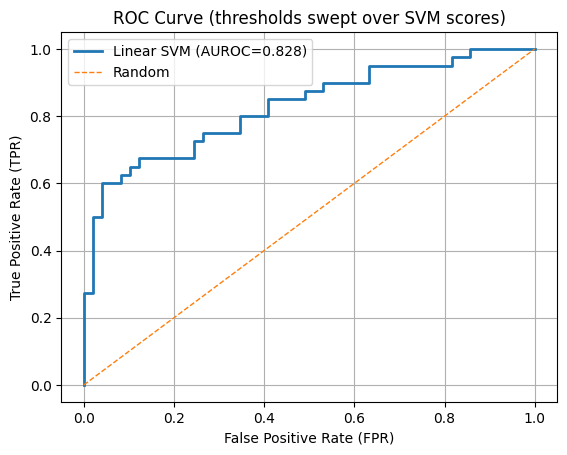

In [10]:

import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Prep labels in {-1, +1} ----------
ytr = np.where(y_train==1, 1.0, -1.0)
yte = np.where(y_test==1,  1.0, -1.0)

# Add bias term by augmenting X with a column of ones
def add_bias(X):
    return np.c_[X, np.ones(len(X))]

Xtr = add_bias(X_train)
Xte = add_bias(X_test)

# ---------- 2) Train a linear SVM (primal, hinge loss) ----------
# Minimize: 0.5*||w||^2 + C * sum(max(0, 1 - y_i * (x_i·w)))
def fit_linear_svm(X, y, C=1.0, lr=1e-2, epochs=200, batch_size=256, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    w = np.zeros(d)  # includes bias as last coordinate
    for _ in range(epochs):
        idx = rng.permutation(n)
        for start in range(0, n, batch_size):
            bidx = idx[start:start+batch_size]
            Xb, yb = X[bidx], y[bidx]
            margins = yb * (Xb @ w)
            # gradient of hinge part: -C * sum_{m<1} y_i x_i
            mask = margins < 1.0
            grad = w - C * (Xb[mask].T @ (yb[mask]))  # d/dw [0.5||w||^2] = w
            w = w - lr * grad
    return w

w = fit_linear_svm(Xtr, ytr, C=1.0, lr=5e-3, epochs=400, batch_size=256, seed=42)

# ---------- 3) Scores (a.k.a. SVM decision values / margins) ----------
# Use score s(x)=x·w ; larger => more likely positive
scores_test = Xte @ w

# ---------- 4) ROC from scratch by threshold sweeping ----------
def roc_from_scores(scores, y_true):  # y_true in {-1,+1}
    # thresholds: sweep from +inf to -inf
    thr = np.r_[np.inf, np.unique(scores)[::-1], -np.inf]
    P = np.sum(y_true == 1)
    N = np.sum(y_true == -1)
    TPR, FPR = [], []
    for t in thr:
        yhat = np.where(scores >= t, 1.0, -1.0)
        TP = np.sum((yhat== 1) & (y_true== 1))
        FP = np.sum((yhat== 1) & (y_true==-1))
        TPR.append(TP / P if P else 0.0)
        FPR.append(FP / N if N else 0.0)
    return np.array(FPR), np.array(TPR)

fpr, tpr = roc_from_scores(scores_test, yte)

# ---------- 5) AUROC via trapezoidal rule (optional but nice) ----------
def auc_trapz(x, y):
    # assumes x sorted asc (our fpr is)
    return np.trapz(y, x)

auroc = auc_trapz(fpr, tpr)
print(f"AUROC = {auroc:.4f}")

# ---------- 6) Plot ----------
plt.figure()
plt.plot(fpr, tpr, lw=2, label=f'Linear SVM (AUROC={auroc:.3f})')
plt.plot([0,1],[0,1],'--', lw=1, label='Random')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve (thresholds swept over SVM scores)')
plt.legend()
plt.grid(True)
plt.show()


#### Task 1.3 (5 Points)
Compute the AUC of ROC.

AUC stands for "Area under the ROC Curve." That is, AUC measures the entire two-dimensional area underneath the entire ROC curve (think integral calculus) from (0,0) to (1,1). AUC provides an aggregate measure of performance across all possible classification thresholds. One way of interpreting AUC is as the probability that the model ranks a random positive example more highly than a random negative example. Describe what the AUC tells us in the context of disease Z.

**Note that you are not allowed to use any library function to compute the AUC. You have to do it from scratch (with NumPy).**

In [ ]:
## Your code to compute the AUC goes here

In [11]:
auroc = auc_trapz(fpr, tpr)
print(f"AUROC = {auroc:.4f}")


AUROC = 0.8281


/tmp/ipython-input-2652466557.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, x)


In [13]:
def auc_from_scores(scores, y_true):
    # y_true in {0,1}. Works directly from scores, no ROC curve needed.
    scores = np.asarray(scores)
    y_true = np.asarray(y_true)
    pos = scores[y_true == 1]
    neg = scores[y_true == 0]

    gt = (pos[:, None] >  neg[None, :]).mean()
    eq = (pos[:, None] == neg[None, :]).mean()
    return gt + 0.5 * eq

def auc_from_scores_sort(scores, y_true):
    scores = np.asarray(scores)
    y_true = np.asarray(y_true).astype(bool)
    # ranks with average for ties
    order = np.argsort(scores)
    ranks = np.empty_like(order, dtype=float)
    i = 0
    while i < len(order):
        j = i
        while j+1 < len(order) and scores[order[j+1]] == scores[order[i]]:
            j += 1
        r = (i + j) / 2.0 + 1.0
        ranks[order[i:j+1]] = r
        i = j + 1
    n_pos = y_true.sum()
    n_neg = (~y_true).sum()
    sum_pos_ranks = ranks[y_true].sum()
    # Mann–Whitney U for positives:
    U = sum_pos_ranks - n_pos * (n_pos + 1) / 2.0
    return U / (n_pos * n_neg)


In [14]:
# y_test in {0,1}, scores_test are the raw SVM decision values
print("AUC (trapz over ROC):", auc_trapz(fpr, tpr))
print("AUC (ranking view) :", auc_from_scores_sort(scores_test, y_test))


AUC (trapz over ROC): 0.828061224489796
AUC (ranking view) : 0.8280612244897959


/tmp/ipython-input-2652466557.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, x)


### Question 2: Maximum likelihood Estimation (MLE) vs Maximum A Posteriori (MAP) Estimation (25 points)

In Homework 1, we performed linear and ridge regression. To summarize:

In Linear regression,

$$\boldsymbol{\hat{\beta}}_{\mathrm{linear}} = \arg\min_{\boldsymbol{\beta}} J(\boldsymbol{\beta}), \quad J(\boldsymbol{\beta}) = \sum_{i=1}^N \left(y^i - \left(\beta_0 + \beta_1 x_{1}^i +, \ldots, + \beta_p x_{p}^i\right)\right)^2$$


* $J(\boldsymbol{\beta})$ is the cost function.
* $\boldsymbol{\beta} = [\beta_0,\ldots,\beta_p] \in \mathbb{R}^p$ are the coefficients for the features $\mathbf{x} = [x_{1},\ldots,x_{p}] \in \mathbb{R}^p$.
* In our dataset, we have $N$ features and its corresponding targets, that is, $D = \{(\mathbf{x}^i, y^i)\}_{i=1}^N$.
* $x_{j}^i$ represents the values of the j-th feature for the i-th observation.
* $y^i$ is the target value for the i-th observation.

For ridge regression

$$\boldsymbol{\hat{\beta}}_{\mathrm{ridge}} = \arg\min_{\boldsymbol{\beta}} J(\boldsymbol{\beta}, \lambda), \quad J(\boldsymbol{\beta}, \lambda) = \sum_{i=1}^N \left(y^i - \left(\beta_0 + \beta_1 x_{1}^i +, \ldots, + \beta_p x_{p}^i \right)\right)^2 + \lambda \cdot \sum \beta_i^2$$

* $\lambda$ is the regularization hyper-parameter.

#### Task 2.1 (5 points)
Linear regression embodies Maximum Likelihood Estimation (MLE). Show that a closed form expression is $$\boldsymbol{\hat{\beta}}_{\mathrm{linear}} = (\mathbf{A}^\top \mathbf{A})^{-1}\mathbf{A}^\top \mathbf{y}$$ where $\mathbf{A} = [\mathbf{x}^1,\ldots,\mathbf{x}^n]$ and $\mathbf{y} = [y^1,\ldots,y^n]$.

####Task 2.2 (5 points)
Ridge regression embodies Maximum A Posteriori (MAP), wherein the regularizer serves as the prior. Show that a closed form expression for the ridge estimator is $$\boldsymbol{\hat{\beta}}_{\mathrm{ridge}} = (\mathbf{A}^\top \mathbf{A} + \lambda \mathbf{I})^{-1}\mathbf{A}^\top \mathbf{y}$$ where $\mathbf{A} = [\mathbf{x}^1,\ldots,\mathbf{x}^n]$ and $\mathbf{y} = [y^1,\ldots,y^n]$.

####Task 2.3 Implementation (10 points)
Fill in the code below to differentiate between MLE and MAP.

####Task 2.4 (5 points)
* Do MLE and MAP yield distinct solutions as the sample size tends to infinity? Explain your answer using formal mathematical reasoning or proofs.

* Will the impact of prior be greater with a small or large sample size, and what is the underlying rationale for this phenomenon? Explain your answer using formal mathematical reasoning or proofs.



# Q2: Maximum Likelihood Estimation (MLE) vs Maximum A Posteriori (MAP)

Assume the linear model
$$
y = A\beta + \varepsilon,\qquad \varepsilon \sim \mathcal N(0,\sigma^2 I_n),
$$
with design matrix \(A\in\mathbb R^{n\times p}\), response \(y\in\mathbb R^{n}\), and coefficients \(\beta\in\mathbb R^{p}\).
(Include a column of ones in \(A\) if you want an intercept.)

---

## 2.1 Linear Regression = MLE, and its Closed Form

### Likelihood \(\rightarrow\) Least Squares
The likelihood is
$$
p(y\mid A,\beta,\sigma^2)
= (2\pi\sigma^2)^{-n/2}\exp\!\left(-\frac{1}{2\sigma^2}\|y-A\beta\|_2^2\right).
$$

So the log-likelihood (ignoring constants in \(\beta\)) is
$$
\ell(\beta)= -\frac{1}{2\sigma^2}\|y-A\beta\|_2^2 + \text{const}.
$$

Maximizing \(\ell(\beta)\) is equivalent to minimizing the sum of squares
$$
J(\beta)=\|y-A\beta\|_2^2.
$$

### Normal Equations and Solution
Expand and differentiate:
$$
J(\beta)= y^\top y -2\beta^\top A^\top y + \beta^\top A^\top A\,\beta,
\qquad
\nabla_\beta J(\beta)= -2A^\top y + 2A^\top A\,\beta.
$$

Set the gradient to zero:
$$
A^\top A\,\hat\beta = A^\top y.
$$

If \(A^\top A\) is invertible (full column rank),
$$
\boxed{\hat\beta_{\text{linear}}=(A^\top A)^{-1}A^\top y.}
$$

(If not invertible, use the Moore–Penrose pseudoinverse: \(\hat\beta=A^+y\).)





## 2.2
Model: \(y = A\beta + \varepsilon\), \(\varepsilon\sim\mathcal N(0,\sigma^2 I)\).

**Ridge optimization**
\[
\hat\beta_{\text{ridge}}
= \arg\min_\beta \|y-A\beta\|_2^2+\lambda\|\beta\|_2^2
\;\Rightarrow\;
(A^\top A+\lambda I)\hat\beta = A^\top y
\]
\[
\boxed{\hat\beta_{\text{ridge}}=(A^\top A+\lambda I)^{-1}A^\top y}
\]

**MAP view**
Prior: \(\beta\sim\mathcal N(0,\tau^2 I)\).
Maximizing the posterior is equivalent to minimizing
\(\|y-A\beta\|_2^2 + (\sigma^2/\tau^2)\|\beta\|_2^2\).
Thus ridge = MAP with
\[
\boxed{\lambda=\sigma^2/\tau^2}.
\]

---

## 2.3
Compute \(\hat\beta_{\text{MLE}}=(A^\top A)^{-1}A^\top y\) and  
\(\hat\beta_{\text{MAP}}=(A^\top A+\lambda I)^{-1}A^\top y\) and compare.

---

## 2.4
**(a) Do MLE and MAP differ as \(n\to\infty\)?**  
No (under standard conditions with fixed \(p\)). Since \(A^\top A\propto n\),
\[
(A^\top A+\lambda I)^{-1}A^\top y
=
\Big(\tfrac1n A^\top A+\tfrac{\lambda}{n}I\Big)^{-1}\!\Big(\tfrac1n A^\top y\Big)
\;\xrightarrow{p}\; \beta^\star.
\]
The \(\lambda/n\) term vanishes, so MLE = MAP in the limit.

**(b) When is the prior’s impact larger? Why?**  
Stronger with **small samples** (or ill-conditioned design): eigenvalues of \(A^\top A\) are small, so ridge shrinkage is large.  
With **large samples**, \(A^\top A\) grows with \(n\), shrinkage \(\to 0\), and the prior matters little.


In [16]:
import numpy as np

# ---------- helpers ----------
def add_bias(X):
    """Append a column of ones (intercept)."""
    return np.c_[X, np.ones(len(X))]

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# ---------- MLE: ordinary least squares ----------
def mle_linear_regression(X, y):
    """
    Returns theta for OLS using the stable pseudoinverse.
    X should be WITHOUT bias; we add it inside.
    theta shape: (d+1,) with last entry = intercept.
    """
    Xb = add_bias(X)
    theta = np.linalg.pinv(Xb) @ y  # (X^+) y
    return theta

def predict_linear(X, theta):
    Xb = add_bias(X)
    return Xb @ theta

# ---------- MAP: ridge regression (L2); no penalty on bias ----------
def map_linear_regression(X, y, lambda_reg):
    """
    Returns theta for ridge: (X^T X + λI*)^{-1} X^T y,
    where I* does NOT penalize the intercept term.
    """
    Xb = add_bias(X)                    # n x (d+1)
    A = Xb.T @ Xb                       # (d+1) x (d+1)
    reg = np.eye(A.shape[0])
    reg[-1, -1] = 0.0                   # don't penalize bias
    theta = np.linalg.solve(A + lambda_reg * reg, Xb.T @ y)
    return theta

# ---------- use them ----------
# assume you already have: X_train, X_test, y_train, y_test (1D arrays)

theta_mle  = mle_linear_regression(X_train, y_train)
y_preds_mle = predict_linear(X_test, theta_mle)
mse_mle    = mse(y_test, y_preds_mle)
print(f"MSE using MLE: {mse_mle:.6f}")

lambda_reg = 0.01
theta_map  = map_linear_regression(X_train, y_train, lambda_reg)
y_preds_map = predict_linear(X_test, theta_map)
mse_map    = mse(y_test, y_preds_map)
print(f"MSE using MAP (ridge, λ={lambda_reg}): {mse_map:.6f}")


MSE using MLE: 0.160671
MSE using MAP (ridge, λ=0.01): 0.162024


### Question 3: Classification with imbalanced dataset (35 points)

To mimic a common scenario in the real-world, we will create an imbalanced version of the target variable for the Z dataset. In our case, we will consider the two classes as follows:

- Class 0: Z progression values that are below the 75th percentile of the original target variable.
- Class 1: Z progression values that are above the 75th percentile of the original target variable.

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split

# --- 1) Make the imbalanced labels (75th percentile) ---
X = X_orig.copy()
y_cont = y_orig.copy()
thr = np.percentile(y_cont, 75)
y_bin = (y_cont > thr).astype(int)          # 1 if above 75th percentile, else 0

# quick sanity check of imbalance
pos = y_bin.sum()
neg = len(y_bin) - pos
print(f"Class counts -> 0: {neg}, 1: {pos}  (positive rate = {pos/len(y_bin):.3f})")

Class counts -> 0: 331, 1: 111  (positive rate = 0.251)


In [20]:
# --- 2) Train/test split (shuffles by default) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, shuffle=True
)

# Optional but helpful: standardize using train stats
mu, sigma = X_train.mean(axis=0), X_train.std(axis=0) + 1e-8
X_train = (X_train - mu) / sigma
X_test  = (X_test  - mu) / sigma



####Task 3.1 (15 points)
Create a SVM classifier with a linear kernel, then calculate accuracy, precision, recall, and F1 score for all classes (**Hint:** you should reuse the functions from Task 1).

Some background knowledge about SVM with a linear kernel is shown below.

The hinge loss $L_i$ for the $i$-th sample is written as:

$$L^i = \max(0, 1 - y^i (\mathbf{w} \cdot \mathbf{x}^i - b))$$

* $\mathbf{w} \cdot \mathbf{x}^i - b$ is the model's prediction score. A positive score predicts class 1, and a negative score predicts class -1.
* **$y^i (\mathbf{w} \cdot \mathbf{x}^i - b)$**: This checks if the prediction is correct. If the value is $\ge 1$, the prediction is correct and outside the margin.
* **$\max(0, 1 - y^i (\mathbf{w} \cdot \mathbf{x}^i - b))$**: This is the "hinge." If a point is classified correctly and confidently (outside the margin), the loss is **0**. Otherwise, the loss is a positive value that grows the more incorrect the prediction is. The full objective function combines the average hinge loss with a regularization term that maximizes the margin:

$$J(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} \max(0, 1 - y^i (\mathbf{w} \cdot \mathbf{x}^i - b)) + \lambda ||\mathbf{w}||^2 $$Here, the regularization term $\lambda ||\mathbf{w}||^2$ penalizes large weights, which is mathematically equivalent to finding a wider margin.

**Hint**: Just like in **logistic regression where you use gradient descent to minimize binary cross-entropy loss**, you can use **gradient descent (or its variants) to minimize the hinge loss** for a linear SVM. By repeatedly calculating the gradient of this objective function and updating the weights $\mathbf{w}$ and bias $b$, the model will gradually converge to the optimal separating hyperplane.

In [ ]:
### Add code here

In [22]:
# --- 3) Linear SVM (hinge loss) from scratch with L2 on w (not on b) ---
def train_linear_svm_hinge(X, y01, lam=1e-2, lr=5e-3, epochs=30, batch=256, seed=0):
    import numpy as np
    # Convert to numpy if DataFrame/Series
    if hasattr(X, "to_numpy"): X = X.to_numpy(dtype=float)
    y01 = np.asarray(y01).astype(int).ravel()

    y = np.where(y01==1, 1.0, -1.0)
    n, d = X.shape
    rng = np.random.default_rng(seed)
    w = np.zeros(d); b = 0.0

    for _ in range(epochs):
        idx = rng.permutation(n)
        for s in range(0, n, batch):
            I = idx[s:s+batch]
            Xb, yb = X[I], y[I]        # now safe: X is ndarray
            margins = 1.0 - yb * (Xb @ w - b)
            mask = margins > 0.0
            if np.any(mask):
                Xv, yv = Xb[mask], yb[mask]
                grad_w = (-(Xv.T @ yv) / len(Xb)) + 2.0*lam*w
                grad_b =  (yv.sum()) / len(Xb)
            else:
                grad_w = 2.0*lam*w; grad_b = 0.0
            w -= lr * grad_w
            b -= lr * grad_b
    return w, b

def decision_function(X, w, b):
    return X @ w - b

def predict_labels(scores):
    return (scores >= 0).astype(int)

# --- train ---
w, b = train_linear_svm_hinge(X_train, y_train, lam=1e-2, lr=5e-3, epochs=50, batch=256, seed=42)


####Task 3.2 (5 points)
What causes the metrics (accuracy, precision, recall, and F1 score) to exhibit lower values for the imbalanced dataset compared to those in homework 1? Please compare with your results for Q5.4 in HW1. Please also use the functions you implemented for Question 1 to do the calculation for the metrics.

In [23]:
# --- 4) Evaluate ---
scores = decision_function(X_test, w, b)
y_pred = predict_labels(scores)

def metrics(y_true, y_pred):
    tp = np.sum((y_true==1) & (y_pred==1))
    tn = np.sum((y_true==0) & (y_pred==0))
    fp = np.sum((y_true==0) & (y_pred==1))
    fn = np.sum((y_true==1) & (y_pred==0))
    acc = (tp+tn) / len(y_true)
    prec = tp / (tp+fp) if (tp+fp) else 0.0
    rec  = tp / (tp+fn) if (tp+fn) else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    return acc, prec, rec, f1

acc, prec, rec, f1 = metrics(y_test, y_pred)
print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")

Accuracy: 0.7978  Precision: 0.5484  Recall: 0.8095  F1: 0.6538


**Random oversampling** is one of the many techniques used to address the class imbalance problem. It involves increasing the number of instances in the minority class by randomly duplicating existing instances. This helps to balance the class distribution and can lead to improved performance for certain models.

####Task 3.3 (4 points)
Calculate and display the following statistics for the target variable (y) before applying random oversampling:
  - Mean
  - Standard Deviation
  - Minimum
  - Maximum

####Task 3.4 (5 points)
Write a function to perform weigthed random oversampling on the training set. Specifically, assign a weight to each example depending on the class to which it belongs. The weights should be inversely proportional to the number of examples in that class. In other words, examples in the low prevelance class will have higher weights and the examples in the high prevelance class will have lower weights. You can read more about WeightedRandomSampler in PyTorch.
Create a new dataset of the same size as the original dataset, whose examples are drawn using the weighted random oversampler you've just implemented.
After oversampling, calculate and display the same statistics for the target variable of the oversampled dataset.

In [24]:
# Apply Random Oversampling
import numpy as np

# ---------- Task 3.3: stats BEFORE oversampling (on the TRAIN set) ----------
def show_stats(name, y):
    y = np.asarray(y).ravel()
    print(f"{name} -> mean: {y.mean():.4f}, std: {y.std(ddof=0):.4f}, "
          f"min: {y.min()}, max: {y.max()}, "
          f"class counts: 0->{np.sum(y==0)}, 1->{np.sum(y==1)}")

show_stats("Before oversampling (train y)", y_train)

Before oversampling (train y) -> mean: 0.2550, std: 0.4358, min: 0, max: 1, class counts: 0->263, 1->90


In [25]:
# ---------- Task 3.4: weighted random oversampling (NumPy) ----------
def weighted_oversample_numpy(X, y, size=None, seed=42):
    """
    Oversample with replacement using weights inversely proportional to class counts.
    Returns X_os, y_os with length 'size' (default: len(y)).
    """
    rng = np.random.default_rng(seed)
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    # class counts and weights
    n0, n1 = np.sum(y==0), np.sum(y==1)
    w0 = 1.0 / max(n0, 1)
    w1 = 1.0 / max(n1, 1)
    w = np.where(y==1, w1, w0)
    p = w / w.sum()

    m = len(y) if size is None else size
    idx = rng.choice(len(y), size=m, replace=True, p=p)
    return X[idx], y[idx]

# Make an oversampled TRAIN set of the SAME size as the original train set
X_train_os, y_train_os = weighted_oversample_numpy(X_train, y_train, size=len(y_train), seed=42)

# Stats AFTER oversampling
show_stats("After oversampling (train y_os)", y_train_os)

After oversampling (train y_os) -> mean: 0.5071, std: 0.4999, min: 0, max: 1, class counts: 0->174, 1->179


####Task 3.5 (6 points)
- Create another instance of SVM classifier with linear kernel, fit it on the oversampled data and calculate all the prior metrics for the oversampled model.Show the metrics with barplots.

- Show the metrics (accuracy, precision, recall, and F1 score) with different regularization parameters {0.1, 1, 10, 100} on the linear kernel. What did you expect with increase in the regularization parameters? Did your expectation align with the observation?

- Show the metrics (accuracy, precision, recall, and F1 score) with polynomial degrees {0, 1, 3, 4}. What do you expect with increase in the degrees? Did your expectation align with the observation?

Please also use the functions you implemented for Question 1 to do the calculation for the metrics.

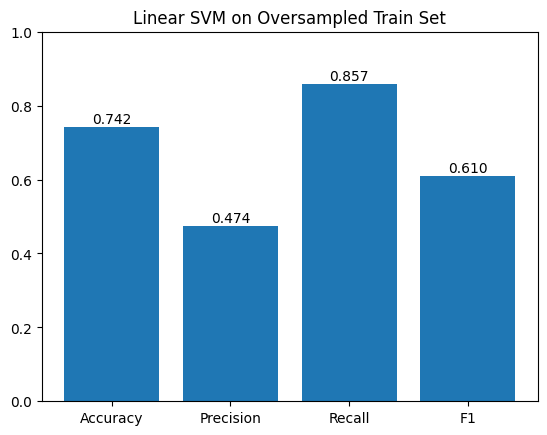

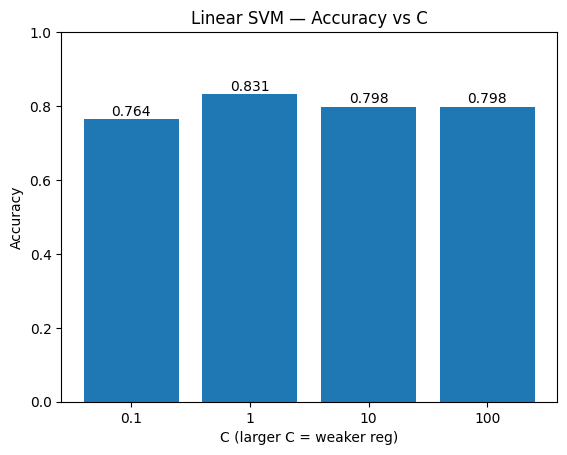

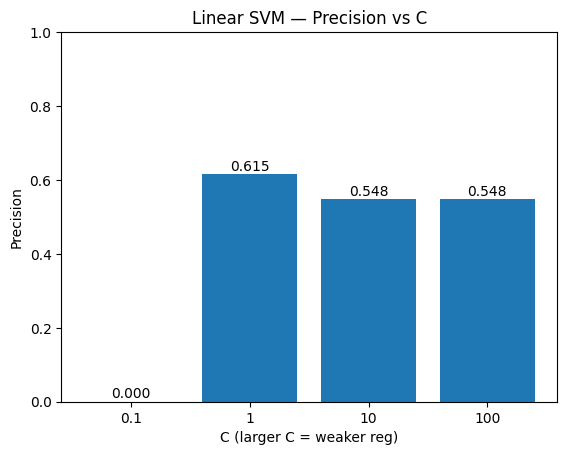

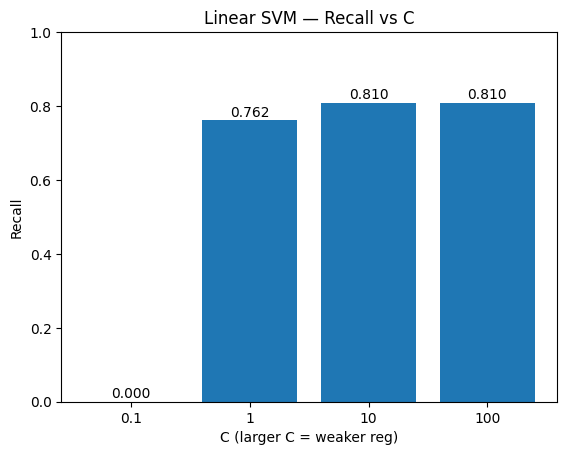

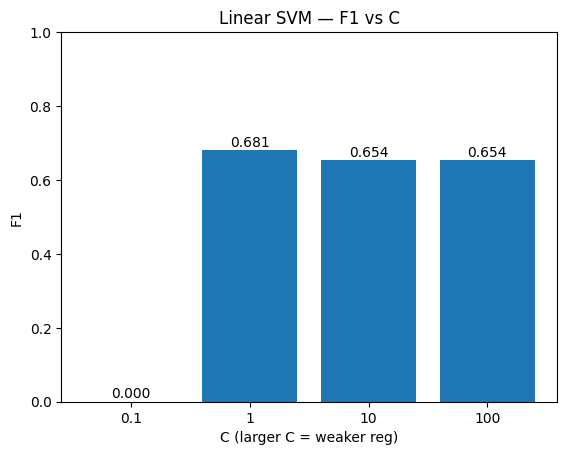

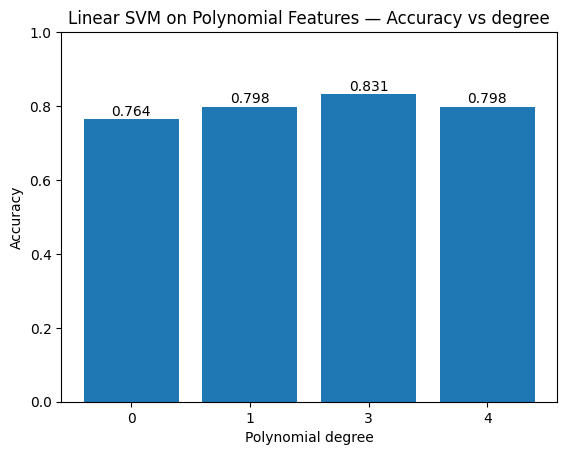

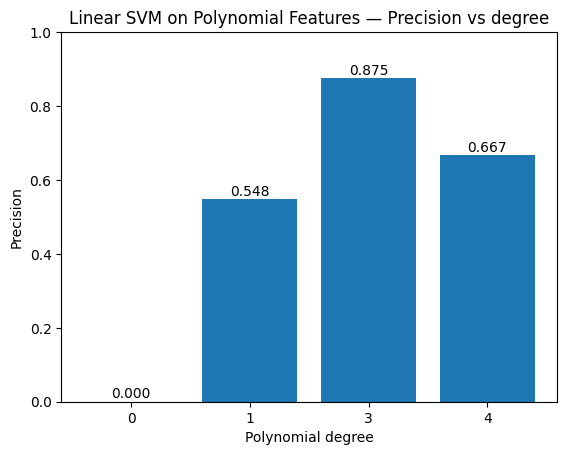

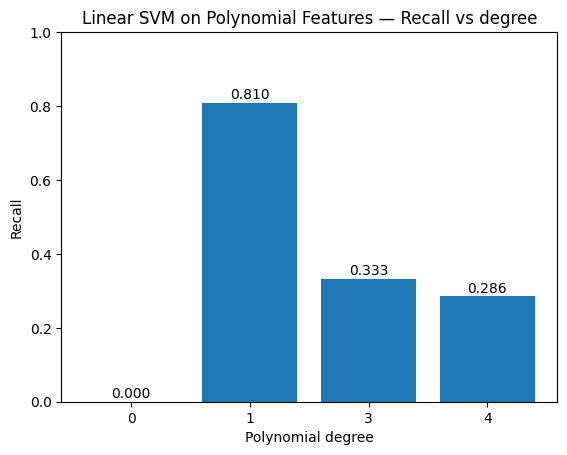

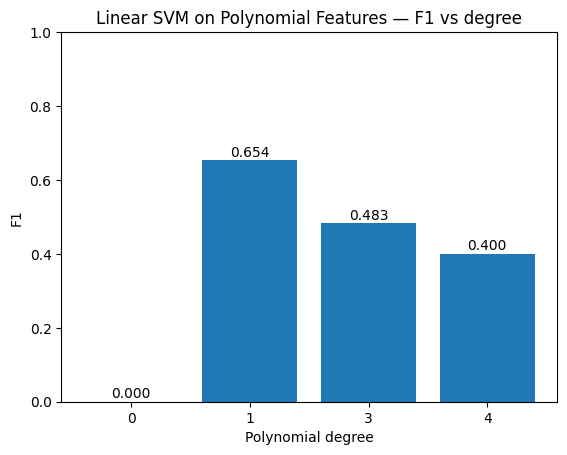

In [26]:
### Add code here
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement

# --- ensure numpy arrays ---
X_train = np.asarray(X_train, float); X_test = np.asarray(X_test, float)
y_train = np.asarray(y_train, int).ravel(); y_test = np.asarray(y_test, int).ravel()

# ---------- helper: evaluate one SVM run ----------
def eval_svm(Xtr, ytr, Xte, yte, lam=1e-2, lr=5e-3, epochs=50, batch=256, seed=42):
    w, b = train_linear_svm_hinge(Xtr, ytr, lam=lam, lr=lr, epochs=epochs, batch=batch, seed=seed)
    scores = Xte @ w - b
    y_pred = (scores >= 0).astype(int)
    acc, prec, rec, f1 = metrics(yte, y_pred)
    return {"acc":acc, "prec":prec, "rec":rec, "f1":f1}

# ---------- (A) Train on OVERSAMPLED set ----------
try:
    X_train_os, y_train_os
except NameError:
    X_train_os, y_train_os = weighted_oversample_numpy(X_train, y_train, size=len(y_train), seed=42)

res_os = eval_svm(X_train_os, y_train_os, X_test, y_test, lam=1e-2)

# barplot for oversampled model
plt.figure()
names = ["Accuracy","Precision","Recall","F1"]
vals = [res_os["acc"], res_os["prec"], res_os["rec"], res_os["f1"]]
plt.bar(names, vals)
plt.ylim(0,1)
plt.title("Linear SVM on Oversampled Train Set")
for i,v in enumerate(vals): plt.text(i, v+0.01, f"{v:.3f}", ha="center")
plt.show()

# ---------- (B) Linear kernel: sweep C ----------
Cs = [0.1, 1, 10, 100]
metrics_lin = []
for C in Cs:
    lam = 1.0 / C   # inverse mapping
    metrics_lin.append(eval_svm(X_train, y_train, X_test, y_test, lam=lam))

# barplots per metric across C
for key, label in [("acc","Accuracy"), ("prec","Precision"), ("rec","Recall"), ("f1","F1")]:
    plt.figure()
    plt.bar([str(c) for c in Cs], [m[key] for m in metrics_lin])
    plt.ylim(0,1); plt.xlabel("C (larger C = weaker reg)"); plt.ylabel(label)
    plt.title(f"Linear SVM — {label} vs C")
    for i,v in enumerate([m[key] for m in metrics_lin]): plt.text(i, v+0.01, f"{v:.3f}", ha="center")
    plt.show()

# ---------- (C) Polynomial features: degrees {0,1,3,4} ----------
def poly_expand(X, degree):
    """
    Full polynomial features up to 'degree' (with interactions), no bias column.
    degree=0 returns an empty (n x 0) design, so model uses only bias 'b'.
    """
    X = np.asarray(X, float)
    n, d = X.shape
    if degree == 0:
        return np.empty((n, 0))
    cols = []
    for deg in range(1, degree+1):
        for comb in combinations_with_replacement(range(d), deg):
            col = np.prod(X[:, comb], axis=1, dtype=float)
            cols.append(col)
    return np.column_stack(cols) if cols else np.empty((n, 0))

degrees = [0, 1, 3, 4]
metrics_poly = []
for deg in degrees:
    Xtr_p = poly_expand(X_train, deg)
    Xte_p = poly_expand(X_test, deg)
    # keep same lam for comparability; you can also tune per degree
    metrics_poly.append(eval_svm(Xtr_p, y_train, Xte_p, y_test, lam=1e-2))

# barplots per metric across degrees
for key, label in [("acc","Accuracy"), ("prec","Precision"), ("rec","Recall"), ("f1","F1")]:
    plt.figure()
    plt.bar([str(d) for d in degrees], [m[key] for m in metrics_poly])
    plt.ylim(0,1); plt.xlabel("Polynomial degree"); plt.ylabel(label)
    plt.title(f"Linear SVM on Polynomial Features — {label} vs degree")
    for i,v in enumerate([m[key] for m in metrics_poly]): plt.text(i, v+0.01, f"{v:.3f}", ha="center")
    plt.show()


### Question 4: Naive Bayes Model (25 points)

- We will assume that the continuous features $\mathbf{x}$ of dimension $D$, follow a Gaussian (normal) distribution within each class $Y$. We can index each element of the feature $\mathbf{x}$ with $j$, that is, $\mathbf{x} = [x_{1},...,x_{D}]$.

- For each class $c$, calculate the mean $(\mu_{jc})$ and standard deviation $(\sigma_{jc})$ for each feature $j$. These parameters represent the central tendency and spread of the feature values within each class.
     
- To make a prediction for a new data point ${\bf x}^0$, calculate the probability of ${\bf x}^0$ belonging to each class $c$ using the Gaussian probability density function:

   \begin{align*}
   p(x_j^0 | Y = c) = \frac{1}{\sqrt{2\pi}\sigma_{jc}} \exp \left({-\frac{1}{2}\left(\frac{x_j^0 - \mu_{jc}}{\sigma_{jc}}\right)^2}\right),
   \end{align*}
  where $\exp$ is the same function as $e$, i.e., $\exp(\zeta) = e^\zeta$ for all $\zeta$.
  Then the class conditional probability $p(Y = c | \mathbf{x}^0 )$ is equal to the product of the probabilities of each feature times the prior of the class

    \begin{align*}
     p(Y = c, \mathbf{x}^0 ) = p(Y=c) p(\mathbf{x}^0 | Y=c) = p(Y = c) \prod_{j=1}^{D} p(x_j^0 | Y = c).
    \end{align*}

- Assign the class label to the class with the highest probability:

    \begin{align*}
     \widehat{Y} = \arg\max_{c} p(Y = c | \mathbf{x}^0)
    \end{align*}

**Hint:** In the code for Gaussian Naive Bayes, we take logarithms in certain calculations. This is a common technique used to avoid numerical underflow, especially when working with small probabilities.

####Task 4.1
First, answer in terms of mathematical notations, what is the prior probability here? Second, calculate prior probability on the dataset explicitly with python code (you may use NumPy).

## Task 4.1
### Definition (math)
For classes \(c \in \{1,\dots,K\}\), the **prior probability** is
\[
\Pr(Y=c) = \pi_c .
\]
The maximum-likelihood estimate (from data) is the class frequency
\[
\hat{\pi}_c = \frac{N_c}{N},
\]
where \(N_c\) is the number of samples with label \(c\) and \(N\) is the total number of samples.

**(Optional Laplace smoothing, \(\alpha \ge 0\))**
\[
\hat{\pi}_c = \frac{N_c + \alpha}{N + \alpha K}.
\]



In [28]:
# python code for prior probability here
import numpy as np

def class_priors(y, smoothing=0.0):
    """
    Returns {class: prior} and log-priors as a dict.
    y can be list/np.array/Series. smoothing = 0 -> plain frequency.
    """
    y = np.asarray(y).ravel()
    classes, counts = np.unique(y, return_counts=True)
    K = len(classes)
    priors = (counts + smoothing) / (len(y) + smoothing * K)
    log_priors = np.log(priors)
    return dict(zip(classes, priors)), dict(zip(classes, log_priors))

# Example: compute on your dataset (use the label vector you want, e.g., y_train or y_bin)
priors, log_priors = class_priors(y_train, smoothing=0.0)
print("priors:", priors)
print("log_priors:", log_priors)

# (If you also want to see oversampled priors)
# priors_os, _ = class_priors(y_train_os)
# print("priors after oversampling:", priors_os)


priors: {np.int64(0): np.float64(0.7450424929178471), np.int64(1): np.float64(0.254957507082153)}
log_priors: {np.int64(0): np.float64(-0.29431402475553214), np.int64(1): np.float64(-1.3666583866030317)}


####Task 4.2
Using the facts obtained above, complete the code below for the Naive Bayes model $p(Y=c|\mathbf{x})$, note that for the `fit()` function, you can use the results you just derived, with the slight modification that you are now working with conditionals $p(x^j | Y)$ rather than $p(z)$.

In [31]:
import numpy as np

class GaussianNaiveBayes:
    """
    NumPy-only Gaussian Naive Bayes.
    Uses log-probabilities to avoid underflow.
    """

    def __init__(self, var_smoothing: float = 1e-9, prior_smoothing: float = 0.0):
        # var_smoothing adds epsilon to variances; prior_smoothing = Laplace alpha
        self.var_eps = var_smoothing
        self.alpha = prior_smoothing
        self.classes = None
        self.parameters = {}   # {c: {"mean": ..., "std": ..., "log_prior": ...}}

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y).ravel()
        self.classes = np.unique(y)
        self.parameters = {}

        N = len(y)
        K = len(self.classes)

        for c in self.classes:
            Xc = X[y == c]                       # samples of class c
            mean = Xc.mean(axis=0)
            var = Xc.var(axis=0) + self.var_eps  # variance with smoothing
            std = np.sqrt(var)

            # class prior with optional Laplace smoothing
            Nc = len(Xc)
            prior = (Nc + self.alpha) / (N + self.alpha * K)

            self.parameters[int(c)] = {
                "mean": mean,
                "std": std,
                "log_prior": np.log(prior)
            }

        return self

    # --- Gaussian log-likelihood of a feature vector under N(mean, std^2) ---
    def _calculate_likelihood(self, x, mean, std):
        # log N(x; mean, std^2) for each feature, then sum across features
        var = std ** 2
        log_prob = -0.5 * (np.log(2.0 * np.pi * var) + ((x - mean) ** 2) / var)
        return np.sum(log_prob)  # scalar

    # --- log p(Y=c | X=x) up to a constant (posterior ∝ prior × likelihood) ---
    def _calculate_class_probability(self, x, c):
        pars = self.parameters[int(c)]
        log_lik = self._calculate_likelihood(x, pars["mean"], pars["std"])
        return pars["log_prior"] + log_lik  # log-posterior up to additive const

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        preds = []
        for xi in X:
            # pick class with highest log-posterior
            scores = [self._calculate_class_probability(xi, c) for c in self.classes]
            preds.append(self.classes[int(np.argmax(scores))])
        return np.asarray(preds)

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == np.asarray(y).ravel())


gnb = GaussianNaiveBayes(var_smoothing=1e-9, prior_smoothing=0.0)
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
accuracy = gnb.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.8202
